Objective :
To build a Convolutional Autoencoder (CAE) that Compresses facial images into a lower-dimensional latent representation and recontructs them with minimal loss of information.
Purpose:
A Convolutional Autoencoder is an unsupervised deep learning model used for:
Image Compression image Reconstruction Feature,Extraction Dimensionality Reduction
The encoder learns a compressed representation (latent space),while the decoder reconstructs the original image from this compressed representation.

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [2]:
!pip install -q kaggle

In [10]:
import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [5]:
!unzip -q celeba-dataset.zip

unzip:  cannot find or open celeba-dataset.zip, celeba-dataset.zip.zip or celeba-dataset.zip.ZIP.


In [22]:
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )

print("Copied", len(images), "images")




Copied 5000 images


In [23]:
IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

In [24]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [25]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [26]:
train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


In [27]:
# build CAE #encoder
input_img= Input(shape=(64, 64,3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)

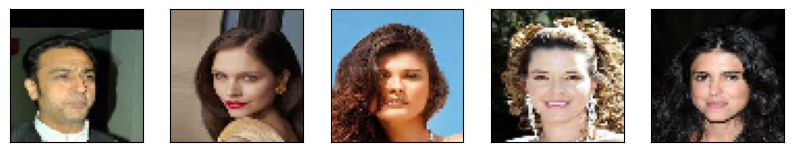

In [28]:
images,_=next(train_generator)

plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])

In [29]:
# build CAE #encoder
input_img= Input(shape=(64, 64,3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)


In [31]:
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
